# Evaluation Metrics

Three important questions that you need to answer:

- How do I choose the model hyperparameters (e.g. n_neighbors?)
- Will the model perform well on new data?
- Which model should I use?

We need evaluation metrics.

- accuracy: percentage of correct classifications
- confusion matrix
- recall (for binary classification problems)
- precision (for binary classification problems)

**Recall** := $\frac{\text{True Positives}}{\text{False Negatives + True Positives}}$

*When the actual label is 1, how often is the prediction correct?*

**Precision** := $\frac{\text{True Positives}}{\text{False Positives + True Positives}}$

*When the predicted is 1, how often is the prediction correct?*

In [1]:
import pandas as pd

path = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/pima.csv'
pima = pd.read_csv(path)

In [2]:
pima

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


Here, each row is a patient and the label indicates whether or not a patient has diabetes

In [3]:
pima.label.mean() # jfc

0.3489583333333333

In [4]:
# feature matrix X, target vector y
y = pima.label
X = pima.drop('label', axis = 1)

In [5]:
# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.75) # default train_size is 0.75

## Evaluation Metrics

In [6]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

In [7]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10)
# train the model
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [9]:
y_test_pred = knn.predict(X_test)

In [10]:
# accuracy
accuracy_score(y_test, y_test_pred)

0.7760416666666666

In [15]:
mat = confusion_matrix(y_test, y_test_pred)

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)

AttributeError: type object 'ConfusionMatrixDisplay' has no attribute 'from_estimator'

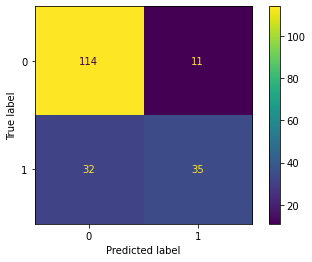

In [19]:
ConfusionMatrixDisplay(mat).plot()

## Cross-Validation

In [23]:
from sklearn.model_selection import cross_val_score

In [24]:
scores = cross_val_score(knn,X,y,cv = 10, scoring = 'accuracy') #cv gives the size of partition

In [25]:
scores

array([0.7012987 , 0.80519481, 0.72727273, 0.7012987 , 0.71428571,
       0.77922078, 0.72727273, 0.80519481, 0.72368421, 0.75      ])

In [28]:
# use the average accuracy as an estimator for the "new-data" accuracy

scores.mean()

0.7434723171565277

**Example 1:** select the best hyperparameters for knn

In [29]:
knn5 = KNeighborsClassifier(n_neighbors=5)
knn10 = KNeighborsClassifier(n_neighbors=10)
knn15 = KNeighborsClassifier(n_neighbors=15)
knn20 = KNeighborsClassifier(n_neighbors=20)

In [31]:
score5 = cross_val_score(knn5,X,y,cv=10,scoring='accuracy').mean()

In [32]:
score10 = cross_val_score(knn10,X,y,cv=10,scoring='accuracy').mean()
score15 = cross_val_score(knn15,X,y,cv=10,scoring='accuracy').mean()
score20 = cross_val_score(knn20,X,y,cv=10,scoring='accuracy').mean()

In [33]:
score5, score10, score15, score20

(0.7213773069036227,
 0.7434723171565277,
 0.7448051948051948,
 0.7461893369788107)

In [34]:
# n_neighbors is best at 20, but at 10 there's not much of a loss

In [36]:
from sklearn.linear_model import LogisticRegression

In [43]:
log_reg = LogisticRegression()
score_log = cross_val_score(log_reg, X, y, cv=10, scoring='accuracy').mean()

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.ht

In [39]:
score_log # logistic regression is a little bit better than knn

0.7721633629528366

**Example 3:** feature selection

In [40]:
X.columns

Index(['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree',
       'age'],
      dtype='object')

In [41]:
# can I drop Glucose?
X_no_gluc = X.drop('glucose', axis=1)

In [44]:
score_log2 = cross_val_score(log_reg, X_no_gluc, y, cv=10, scoring='accuracy').mean()
score_log2

/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.6965652768284347

Upshot: we can drop features, change models, and alter hyperparameters to best fit the problem